# <span style="color:crimson; background-color:white">딥러닝 ② FOCUS ON TRANSFORMER</span>

## <span style="color:crimson; background-color:white">1. 인트로</span>

RNN의 한계: 장기의존성 문제, vanishing gradient  
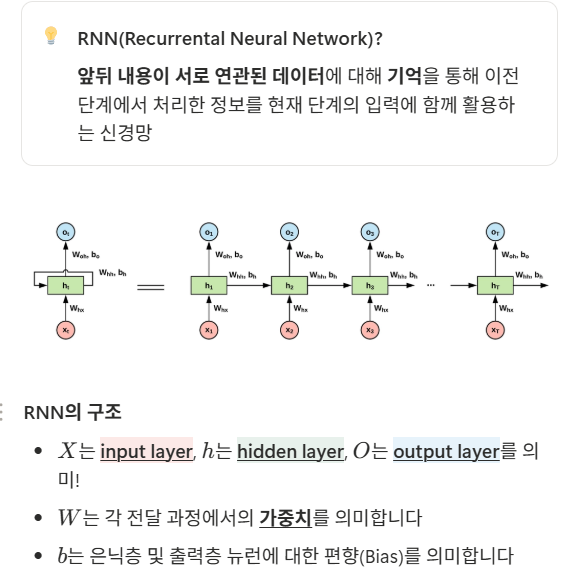  
"기억": "과거 정보가 계속 전달됨"  
가중치 공유: 모든 타임 스템에서 동일한 가중치를 반복해서 사용함
    - 가중치 공유의 장점: (1) 파라미터의 효율성, (2) 학습의 일반화 가능  
vanishing gradient: **초반부 데이터들이 후반부 데이터에 반영되지 않는 문제 발생**

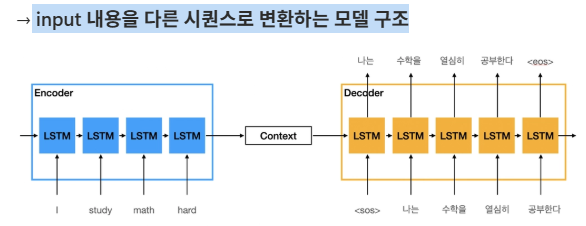  
Seq2Seq: input 내용을 다른 시퀀스로 변환하는 모델 구조

인코더: 원문의 특징 파악  
디코더: 인코더에 의해 만들어진 문맥 벡터를 바탕으로 출력 시퀀스 생성(번역문 생성)

attention  
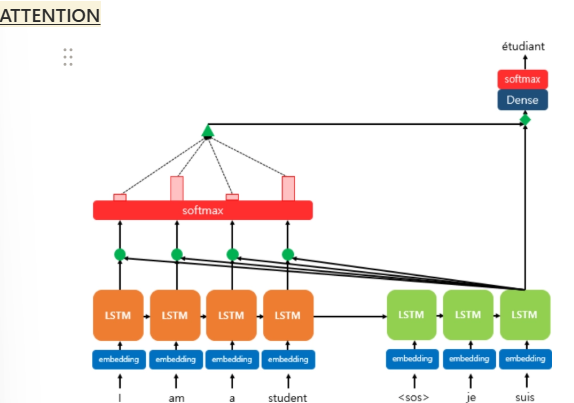  
- 말 그대로 중요한 정보에 더 집중하는 메커니즘  
- 현재 시점에서 가장 중요한 부분에 *더 높은 가중치를 부여*하여 활용  
    - 즉, 출력 단어를 생성할 때 입력 문장 속 단어들 중 어떤 단어에 얼마나 집중할지 결정하는 기술
    - attention 메커니즘의 장점  
    ① 시간 경과에 대한 유연성 (vs RNN)
        - RNN은 장기 의존성 문제 가짐
        - attention은 모든 단어에서 다른 모든 단어로 직접 연결될 수 있음 / 따라서 *아무리 멀리 떨어진 단어 사이의 관계라도 정보 손실 없이 명확하게 파악할 수 있음!
        - 시간적(순서적) 거리에 제약을 받지 않는 유연성 확보  
    ② 공간에 대한 유연성 (vs CNN)  
        -  CNN은 '고정된 필터(Filter)'를 사용해 이미지의 지역적인(local) 부분을 중심으로 정보를 처리
        - Attention은 이미지의 모든 픽셀이 다른 모든 픽셀과 직접 연결되어, 픽셀 간의 거리에 상관없이 한 번에 전체 이미지의 전역적인 관계를 학습할 수 있음
    ③ 병렬화 (vs RNN)  
        - RNN은 구조적으로 순차 계산이 필수적이기 때문에 병렬 처리가 어렵고 학습 속도가 매우 느리다는 단점
        - Attention은 self-attention에서 문장 내 모든 단어의 관계를 한번에, 독립적으로 계산할 수 있늠

<span style="color:white; background-color:hotpink">1-2. Attention is All You Need</span>

논문 내용  
- ① 논문 배경 : RNN과 RNN 기반 모델들의 한계점 (느린 학습 속도, 장기 의존성 문제) -> 오직 attention만 쓰는 모델 만들자
- ② Transformer의 등장 -> self-attention에 기반한 transformer 모델을 제안!
- ③ 논문에서 가장 중요한 발견 -> 성공적인 모델링에 Recurrence 및 Convolution이 필수가 아님을 증명, (+) 모든 단어들을 동시에 계산할 수 있는 병렬화가 가능
- ④ 파급효과  
    - LLM의 탄생: 트랜스포머는 BERT와 GPT라는 두 거대 모델의 직접적인 기반이 됨.
    - NLP 평정: 번역, 요약, 챗봇 등 거의 모든 자연어 처리 분야에서 트랜스포머 기반 모델들이 표준으로 자리잡게 됨.
    - 타 분야로의 확장: 트랜스포머의 성공은 AI를 NLP를 넘어 컴퓨터 비전(Vision Transformer), 음성 처리, 신약 개발 등 모든 영역으로 확장시킴.

Transformer는 RNN의 순차적인 계산 방식을 완전히 버리고, 오직 어텐션(Attention)만으로 문장의 의미와 구조를 파악하는 모델

**Transformer의 핵심 기술**

1. **Self-Attention :** **문장 안에서 어떤 단어가 다른 단어들과 얼마나 중요한 관계를 맺고 있는지** 한 번에 파악하는 기술
2. **Multi-Head Attention** : 셀프 어텐션을 **여러 개의 머리(Head)로 동시에, 서로 다른 관점에서 실행합니다.**
3. **Positional Encoding** : 단어의 위치 정보를 벡터에 추가하여 각 단어가 문장의 몇 번째 위치에 존재하는지 알 수 있습니다.  
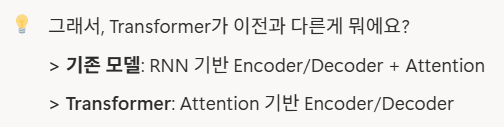  



### <span style="color:crimson; background-color:white">2. Self-Attention</span>

<span style="color:white; background-color:hotpink">2-1. Query, Key, Value</span>

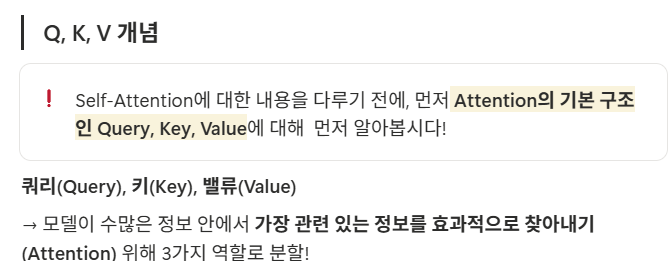  
Q : Query  
쿼리는 말 그대로 '질문' 또는 '요청'으로, 지금 당장 내가 알고 싶거나, 초점을 맞추고 있는 대상  
    - “서강대학교 인사이트 15기 인원”을 확인하기 위해, 검색창에 입력하는 "서강대학교 인사이트 15기 인원"가 바로 Query! 즉, 원하는 것을 찾기 위한 명확한 요청을 의미

K : Key  
키는 검색 대상이 되는 모든 정보들이 달고 있는 '이름표' 또는 '색인' 
쿼리는 이 키들과 자신을 비교하며 얼마나 관련이 있는지 확인힙니다!  
    - 서강대학교 학생 데이터베이스에 있는 ’학번’들이 바로 Key가 된다."서강대학교 인사이트 15기 인원"이라는 검색어를 이 “학번”들과 비교하여 관련도를 측정

V : Value  
밸류는 키와 한 쌍으로 묶여 있는 '실제 내용물'
쿼리와 키의 관련도 계산이 끝나고, 가장 관련성이 높다고 판단된 키가 선택되면, 모델은 그 키에 해당하는 밸류를 가져와 사용함
    - ’학번’(K)이 내 검색어(Q)와 가장 관련 높다고 판단되었을 때, 우리가 최종적으로 보게 되는 학생들에 대한 정보 (나이, 학과, 수강 현황 등등…)가  Value

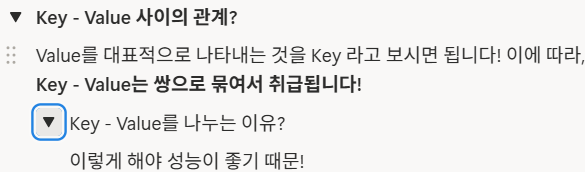 띠용

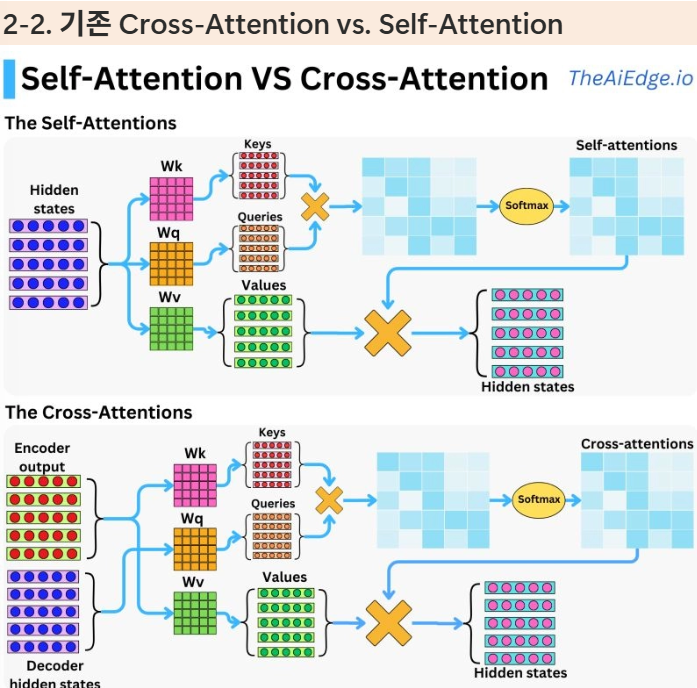  

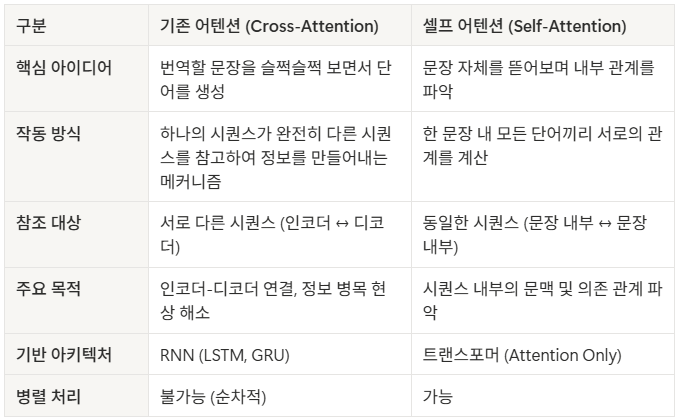  

기존 Attention in Seq2Seq (Cross-Attention)  
번역할 문장을 슬쩍슬쩍 보면서 단어를 생성  
→ Query와  Key - Value쌍이 서로 다른 시퀀스에서 출력  

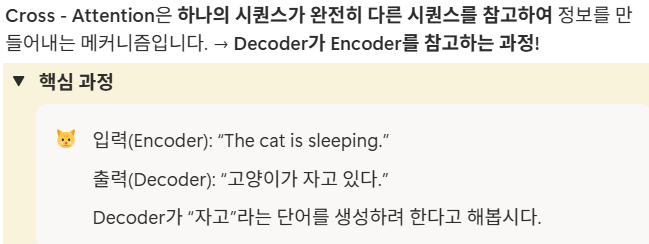  
1. Query 만들기
- 디코더는 지금까지 생성된 단어들("고양이가")를 보고 현재 상태를 하나의 백터(query)로 요약  
즉, "지금 단어를 만드려면 어떤 영어 단어를 참고해야 하지?"라는 질문

2. Key, Value 불러오기
Encoder는 입력 문장("The cat is sleeping")을 처리해 각 단어에 대한 벡터를 가지고 있음  
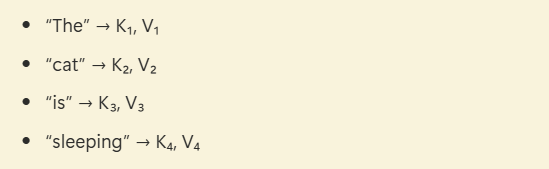  

3. 유사도 계산 (Attention Score)  
Decoder의 Query(Q)가 Encoder의 각 Key(K₁~K₄)와 유사도(관련성)를 계산합니다.  
→ Q · Kᵢ (내적)  
이 값이 “이 단어를 얼마나 참고할지”를 의미함  
“자고” ↔ “sleeping” → 높은 유사도  
“자고” ↔ “The” → 거의 무관  
이 점수들을 softmax로 정규화해서 전체가 1이 되도록 가중치(α)로 변환합니다.  

4. Weighted Sum  
Encoder의 Value(V)들을 그 가중치로 섞어줍니다.  
→ “Decoder가 지금 생성할 단어에 필요한 정보”를 입력 문장 전체에서 **적절히 섞은 하나의 벡터**로 만드는 과정입니다.

5. 디코더가 다음 단어를 예측

이제 Decoder는 **자기 자신의 정보**와 방금 만든 **context vector**를 합쳐서 “고양이가” 다음에 올 단어(“자고”)를 예측합니다.

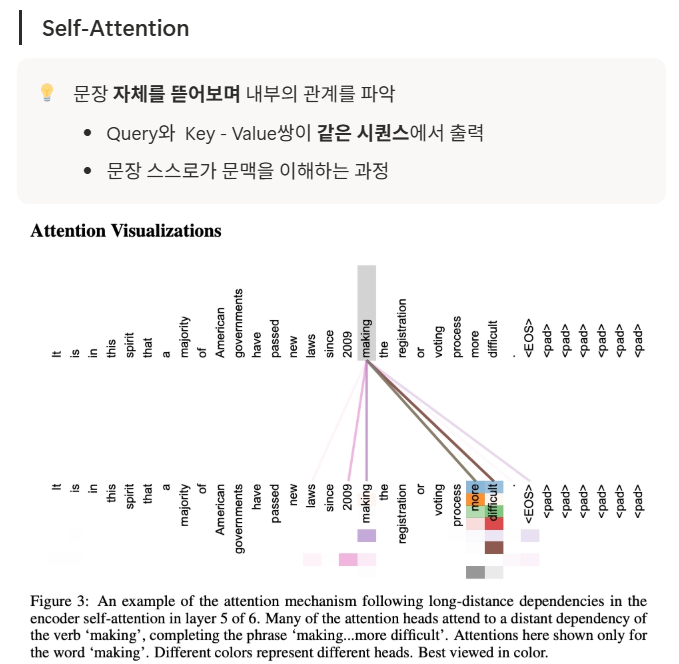  

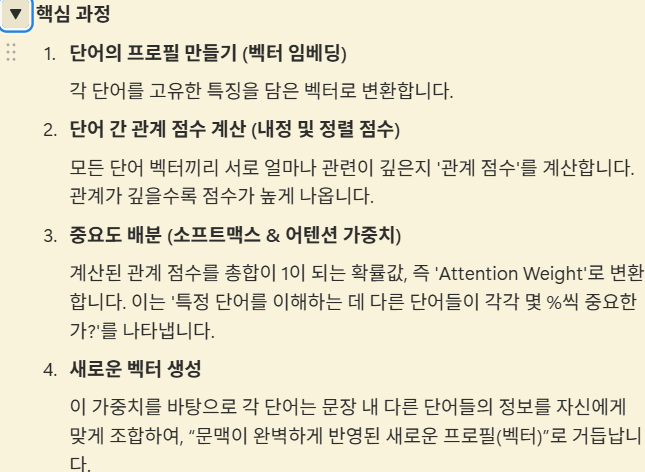  

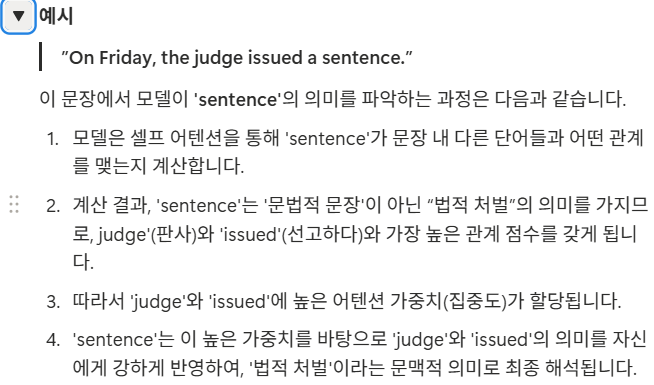  

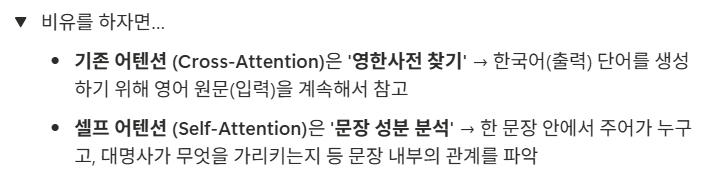

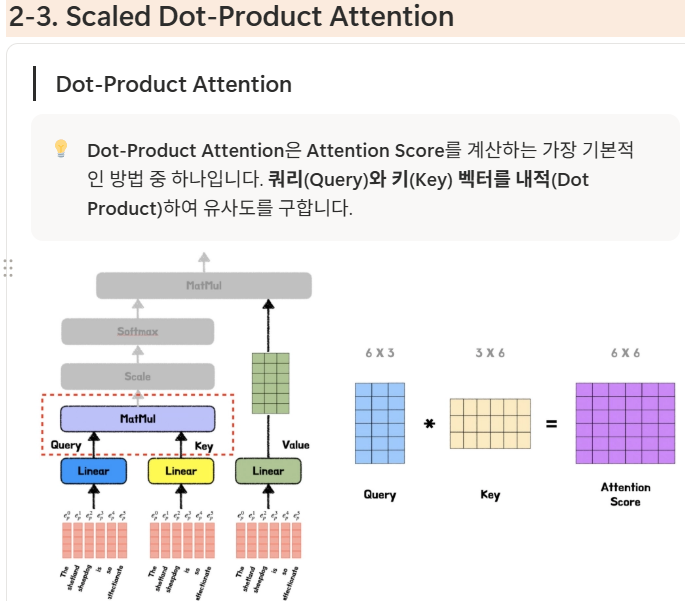

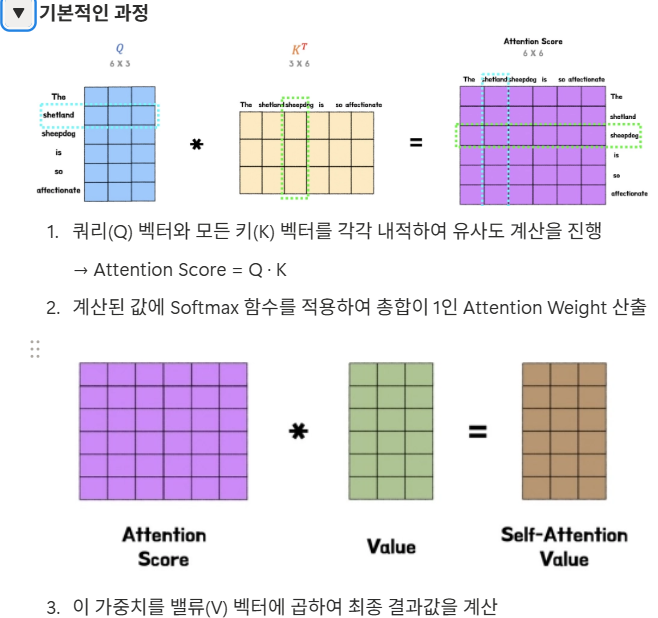

문제점  : Attention Score의 극단화 
벡터 차원d(k)가 커질수록 내적값이 지나치게 커지거나 작아질 수 있습니다. 이런 극단적인 값이 Softmax에 입력되면 특정 단어에 확률이 과도하게 집중되고, gradient가 0에 가까워지는 Vanishing Gradient 문제가 발생할 수 있습니다.

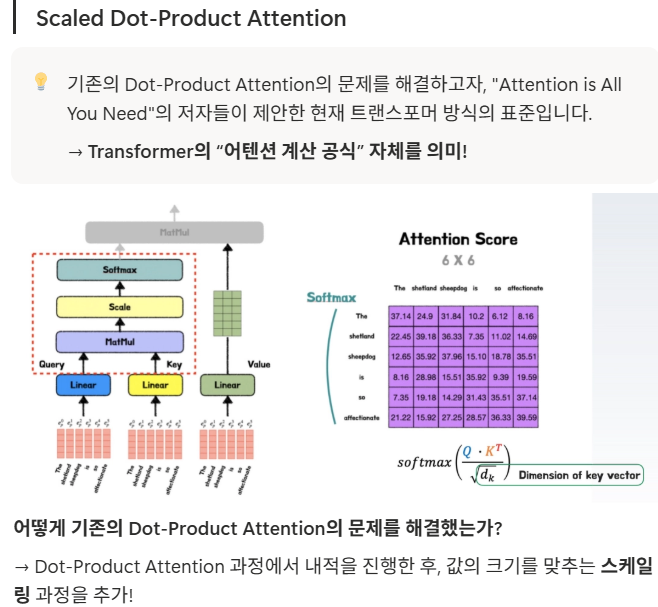



<span style="color:white; background-color:hotpink">3. Multi-Head Attention</span>

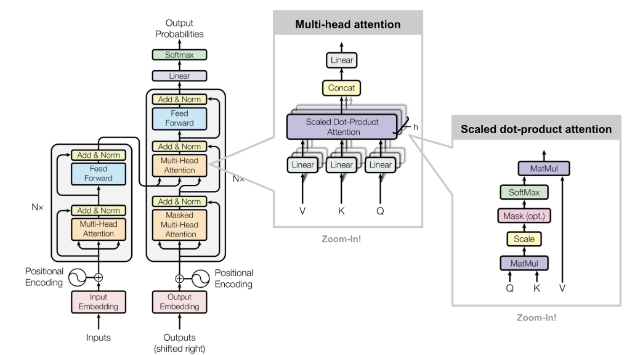

- Encoder(왼쪽 박스 내부)에서는 Multi-Head Attention이 한 번 사용됩니다.
- Decoder(오른쪽 박스 내부)에서는 Multi-Head Attention이 두 번 사용됩니다.
- Masked Multi-Head Attention: 아직 생성되지 않은 미래 단어를 보지 못하도록 가리고, 현재까지 생성된 단어들만 참고합니다.
- Encoder-Decoder Attention:  Decoder가 출력을 생성할 때, Encoder가 이해한 입력 문장 정보를 참고합니다.
- Multi-Head Attention은 Transformer가 토큰들 사이의 관계를 파악하고, 문맥 정보를 반영하여 더 정확한 출력을 만들 수 있도록 도와주는 핵심 구조입니다.

3-1. Why Multi-Head Attention?

Single-Head Attention  
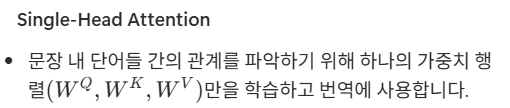

- 작동 방식
- 512차원의 입력 벡터 → 이 벡터를 위한 어텐션 가중치 분포 계산 → 가중합하여 새로운 512차원의 벡터를 출력함
- 한계
 -하나의 어텐션 분포 안에서 각 단어 간 문법적인 관계, 의미적인 관계, 위치 관계 등 모든 종류의 정보를 한 번에 담아 가중 평균을 구해버리기 때문에, 결국 각 단어 간의 중요한 관계를 놓쳐버릴 수 있음

 

3-2. Multi-Head Attention
- 작동 방식
- 입력된 512차원의 벡터를 여러 개의 '헤드'로 나누어 다양한 관점에서 병렬 처리하는 과정입니다.
- 분할 (Projection): 512차원 벡터를 8개의 헤드(각 64차원)로 나눕니다. 각 헤드는 고유한 가중치($W^Q, W^K, W^V$)를 곱해 독립적인 Q, K, V를 생성합니다
- 병렬 어텐션 계산: 각 헤드 내에서 Scaled Dot-Product Attention을 수행합니다.Score: $Q \cdot K^T$를 통해 단어 간 연관성 계산
- Scale & Softmax: 점수를 조절하고 가중치(0~1)로 변환
- Weighted Sum: 가중치를 V에 곱해 문맥이 담긴 64차원 벡터 도출결합 및 최종 투영: 8개의 결과(64차원)를 다시 합쳐(Concatenate) 512차원으로 만들고, 최종 가중치($W^O$)를 곱해 출력합니다.

4-1. 트랜스포머 전처리 (Preprocessing)
모델이 텍스트를 이해할 수 있도록 변환하는 단계입니다.

- 토큰화 (Tokenization): 문장을 모델의 최소 처리 단위(Tokens)로 나눕니다.

- 임베딩 (Embedding): 토큰을 의미를 가진 숫자 벡터로 변환합니다. 유사한 의미의 단어는 공간상에서 가깝게 배치됩니다.

- Positional Encoding: 병렬 처리를 하는 트랜스포머를 위해 단어의 순서 정보를 추가합니다. 사인(Sine)과 코사인(Cosine) 함수를 이용해 고유한 위치 벡터를 더해줍니다.

4-2. Encoder와 Decoder 구조
1️⃣ Encoder (입력 문장 이해)
역할: 입력 문장을 깊이 있게 분석하여 요약된 문맥 벡터를 만듭니다.

주요 구성:

Multi-Head Attention: 단어 간의 관계 파악

Feed-Forward (FFN): 각 단어의 의미를 심층 분석

Residual Connection & Layer Norm: 학습 안정화 및 정보 손실 방지

2️⃣ Decoder (출력 문장 생성)
역할: 인코더의 정보를 바탕으로 출력 단어를 하나씩 순차적으로 생성합니다.

주요 구성:

Masked Multi-Head Attention: 미래의 단어를 미리 보지 못하도록 가림(Masking)

Cross-Attention: 인코더가 만든 정보를 참조하여 출력할 단어 결정

4-3. 전체 데이터 흐름 요약 (번역 예시)
입력: "I love you" → [임베딩 + 위치 정보] 결합.

인코더: Self-Attention을 통해 "love"가 "I"와 "you" 사이에서 갖는 문맥적 의미를 파악하여 벡터로 저장.

디코더:

<start> 입력 → 인코더 정보 참조 → "나는" 생성

"나는" 입력 → 인코더 정보 참조 → "당신을" 생성

반복하여 <end>가 나올 때까지 단어를 생성.